# Objetivo:

Este notebook tem como objetivo apresentar a diferença entre utilizar método ensable random foreste, comparando com decision tree. 

**Contextualização:**

O Random Forest é um método ensamble do tipo Baggin, e ele utiliza centenas de decision trees. 

* Ensamble tipo bagging é um conjunto do mesmo modelo, treinado em diferente amostras dos dados aplicando bootstrap. 

# Importando Bibliotecas e Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#Para salvar gif e faze imagens
from PIL import Image
import io
import warnings
import plotly.graph_objects as go
from plotly.subplots import make_subplots
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [2]:
data = load_breast_cancer()
data.data

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [3]:
# Separar Treino e Teste
X_treino, X_teste, y_treino, y_teste = train_test_split(data.data, data.target, test_size = 0.3,  random_state= 123)

### Importante:
Aqui vamos treinar o modelo em todos os dados, e o PCA entra apenas para visualização final

In [4]:
# Normalizar
scaler = StandardScaler()
X_treino_escala = scaler.fit_transform(X_treino)
X_teste_escala = scaler.transform(X_teste)

In [5]:
# Treinando os dois modelos
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=123)
dt_model.fit(X_treino_escala, y_treino)
# Random Forest
rf_model = RandomForestClassifier(random_state=123)
rf_model.fit(X_treino_escala, y_treino)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
def metrics(model, X_teste, y_teste):
    y_pred = model.predict(X_teste)
    cm = confusion_matrix(y_teste, y_pred)
    accuracy = accuracy_score(y_teste, y_pred)
    print("Acurácia:")
    print(accuracy)
    
    #Fazer imagem da matriz de confusão - Matplotlib com números dos valores
    plt.figure(figsize=(5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Matriz de Confusão')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['Predito Negativo', 'Predito Positivo'])
    plt.yticks(tick_marks, ['Real Negativo', 'Real Positivo'])

    # Adicionar números aos quadrados
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), horizontalalignment="center", verticalalignment="center")

    plt.xlabel('Predição')
    plt.ylabel('Real')
    plt.show()
    
    

Acurácia:
0.9415204678362573


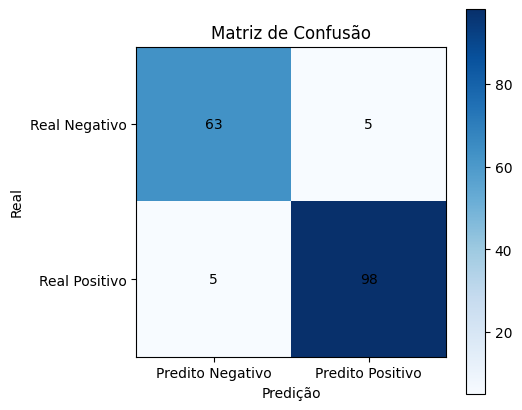

In [7]:
metrics(dt_model, X_teste_escala, y_teste)

Acurácia:
0.9824561403508771


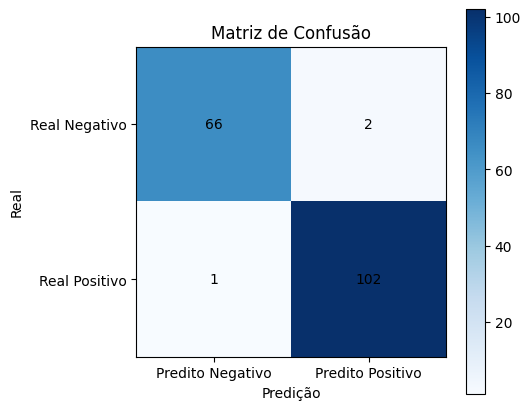

In [8]:
metrics(rf_model, X_teste_escala, y_teste)

* O modelo random forest tem melhor acurácia, conseguindo separada melhor as classes.
* O objetivo é visualizar esta separação

# Visualizando a separação das classes

In [9]:
# PCA para visualização
pca = PCA(n_components=2).fit(X_treino_escala)
X_2d = pca.transform(X_teste_escala)

In [10]:
# Grid no espaço 2D
xx, yy = np.meshgrid(
    np.linspace(X_2d[:, 0].min(), X_2d[:, 0].max(), 200),
    np.linspace(X_2d[:, 1].min(), X_2d[:, 1].max(), 200),
)
grid_2d = np.c_[xx.ravel(), yy.ravel()]
grid_orig = pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])

In [11]:
modelos = {"Árvore de decisão": dt_model, "Random Forest": rf_model}
fig = make_subplots(rows=1, cols=2, subplot_titles=list(modelos), shared_yaxes=True)

for i, (nome, modelo) in enumerate(modelos.items(), start=1):
    Z = modelo.predict(grid_orig).reshape(xx.shape)

    # Fundo: região prevista para cada classe
    fig.add_trace(go.Heatmap(
        x=xx[0], y=yy[:, 0], z=Z, zmin=0, zmax=1, showscale=False,
        colorscale=[[0, "#cfe0f7"], [1, "#f8d9c6"]],
    ), row=1, col=i)

    # Pontos reais por cima
    fig.add_trace(go.Scatter(
        x=X_2d[:, 0], y=X_2d[:, 1], mode="markers", showlegend=False,
        marker=dict(color=y_teste, colorscale=[[0, "#1f6fd1"], [1, "#e0703c"]],
                    size=5, line=dict(width=0.5, color="black")),
    ), row=1, col=i)

fig.update_layout(title="Fronteira de decisão: árvore vs. floresta", width=1000, height=480)
fig.show()

In [12]:
# Refazendo em 3 dimensões
# PCA para visualização
pca3d = PCA(n_components=3).fit(X_treino_escala)
X_3d = pca3d.transform(X_teste_escala)

# Grid no espaço 3D
n = 25
margem = 0.5
eixos = [
    np.linspace(X_3d[:, k].min() - margem, X_3d[:, k].max() + margem, n)
    for k in range(3)
]
xx, yy, zz = np.meshgrid(*eixos, indexing="ij")
grid_3d = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]
grid_orig = pca3d.inverse_transform(grid_3d)

In [13]:
modelos = {"Árvore de decisão": dt_model, "Random Forest": rf_model}

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=list(modelos),
)

for i, (nome, modelo) in enumerate(modelos.items(), start=1):
    # Probabilidade da classe 1 em cada ponto da malha
    prob = modelo.predict_proba(grid_orig)[:, 1]

    # Fronteira de decisão: superfície onde prob = 0.5
    fig.add_trace(go.Isosurface(
        x=xx.ravel(), y=yy.ravel(), z=zz.ravel(), value=prob,
        isomin=0.5, isomax=0.5, surface_count=1,
        opacity=0.5, colorscale=[[0, "gray"], [1, "gray"]],
        showscale=False, caps=dict(x_show=False, y_show=False, z_show=False),
    ), row=1, col=i)

    # Pontos reais por cima
    fig.add_trace(go.Scatter3d(
        x=X_3d[:, 0], y=X_3d[:, 1], z=X_3d[:, 2],
        mode="markers", showlegend=False,
        marker=dict(
            color=y_teste, colorscale=[[0, "#1f6fd1"], [1, "#e0703c"]],
            size=3, line=dict(width=0.5, color="black"),
        ),
    ), row=1, col=i)

fig.update_layout(
    title="Fronteira de decisão 3D: árvore vs. floresta",
    width=1100, height=550,
)
fig.show()

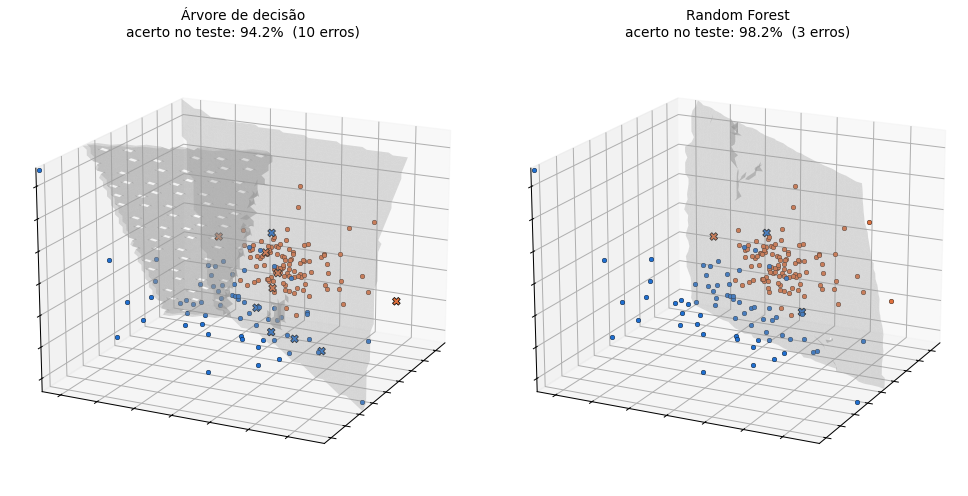

In [ ]:
import io
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from PIL import Image
from skimage import measure

# ---------- Configuração ----------
n = 40
margem = 0.1
nivel = 0.5
N_FRAMES = 90
ELEVACAO = 18
AZIMUTE_INICIAL = 30
DURACAO_MS = 60
ZOOM = 1.07
SAIDA = "../Outcomes/dt_rf_3d.gif"
TREINADO_NO_ESPACO_ORIGINAL = True

COR = {0: "#1f6fd1", 1: "#e0703c"}
modelos = {"Árvore de decisão": dt_model, "Random Forest": rf_model}
rf_model.set_params(n_jobs=-1)

# ---------- PCA e grid ----------
X_3d = pca3d.transform(X_teste_escala)
y = np.asarray(y_teste)

eixos = [np.linspace(X_3d[:, k].min() - margem, X_3d[:, k].max() + margem, n)
         for k in range(3)]
xx, yy, zz = np.meshgrid(*eixos, indexing="ij")
grid_3d = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]

if TREINADO_NO_ESPACO_ORIGINAL:
    grid_modelo = pca3d.inverse_transform(grid_3d).astype(np.float32)
    X_teste_modelo = X_teste_escala
else:
    grid_modelo = grid_3d
    X_teste_modelo = X_3d

spacing = tuple(e[1] - e[0] for e in eixos)
origem = np.array([e[0] for e in eixos])

# ---------- Superfície e previsões ----------
dados = {}
for nome, modelo in modelos.items():
    prob = modelo.predict_proba(grid_modelo)[:, 1]
    P = prob.reshape(n, n, n)
    verts, faces, _, _ = measure.marching_cubes(P, level=nivel, spacing=spacing)
    verts = verts + origem
    dados[nome] = {"tris": verts[faces], "pred": modelo.predict(X_teste_modelo)}

# ---------- Figura ----------
fig = plt.figure(figsize=(11, 5.6), dpi=90)
axes = []
for i, (nome, d) in enumerate(dados.items(), start=1):
    ax = fig.add_subplot(1, 2, i, projection="3d")

    ax.add_collection3d(Poly3DCollection(
        d["tris"], facecolor="#9a9a9a", edgecolor="none", alpha=0.35))

    ok = d["pred"] == y
    for c in (0, 1):
        m = (y == c) & ok
        ax.scatter(*X_3d[m].T, c=COR[c], s=14, edgecolor="k",
                   linewidth=0.3, depthshade=False)
    ax.scatter(*X_3d[~ok].T, c=[COR[c] for c in y[~ok]], s=38, marker="X",
               edgecolor="k", linewidth=0.6, depthshade=False)

    ax.set_title(f"{nome}\nacerto no teste: {ok.mean()*100:.1f}%  ({(~ok).sum()} erros)",
                 fontsize=11)
    ax.set_xlim(eixos[0].min(), eixos[0].max())
    ax.set_ylim(eixos[1].min(), eixos[1].max())
    ax.set_zlim(eixos[2].min(), eixos[2].max())

    ax.set_box_aspect(None, zoom=ZOOM)

    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    axes.append(ax)

fig.subplots_adjust(left=0, right=1, bottom=0, top=0.88, wspace=0)

# ---------- Animação ----------
frames = []
for f in range(N_FRAMES):
    az = AZIMUTE_INICIAL + 360 * f / N_FRAMES
    for ax in axes:
        ax.view_init(elev=ELEVACAO, azim=az)
    buf = io.BytesIO()
    fig.savefig(buf, format="png")
    buf.seek(0)
    frames.append(Image.open(buf).convert("P", palette=Image.ADAPTIVE).copy())

frames[0].save(SAIDA, save_all=True, append_images=frames[1:],
               duration=DURACAO_MS, loop=0, optimize=True)